## Question 5: Friendship Network Analysis

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

friendship_connections = [
    ("Alice", "Bob"),
    ("Alice", "Charlie"),
    ("Bob", "David"),
    ("Charlie", "David"),
    ("David", "Eva"),
    ("Eva", "Frank"),
    ("Charlie", "Frank")
]

G_friendship = nx.Graph()
G_friendship.add_edges_from(friendship_connections)


### Visualization of the Friendship Network

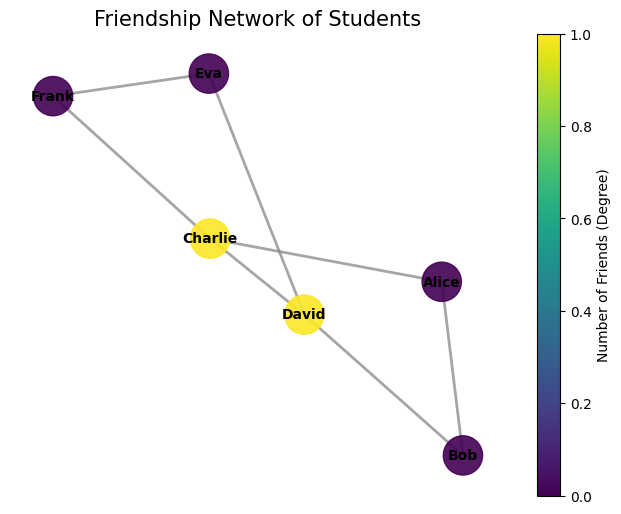

In [ ]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_friendship, seed=42)

node_degrees = dict(G_friendship.degree())
node_colors = [node_degrees[node] for node in G_friendship.nodes()]

nx.draw_networkx_nodes(
G_friendship, pos,
node_color=node_colors,
cmap=plt.cm.viridis,
node_size=800,
alpha=0.9)

nx.draw_networkx_edges(
G_friendship, pos,
width=2,
alpha=0.7,
edge_color='gray',
style='solid')

nx.draw_networkx_labels(
G_friendship, pos,
font_size=10,
font_color='black',
font_weight='bold')

plt.title('Friendship Network of Students', size=15)
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis),
ax=plt.gca(),
orientation='vertical',
label='Number of Friends (Degree)')
plt.axis('off')
plt.show()


### Network Structure Information

In [ ]:
num_nodes = G_friendship.number_of_nodes()
num_edges = G_friendship.number_of_edges()
print(f"Total number of students (nodes): {num_nodes}")
print(f"Total number of friendship connections (edges): {num_edges}")

print("\nDegree of each student (number of friends):")
degrees = dict(G_friendship.degree())
for student, degree in degrees.items():
    print(f"{student}: {degree} friends")

max_degree = max(degrees.values())
highest_degree_students = [student for student, degree in degrees.items() if degree == max_degree]
print(f"\nStudent(s) with the highest number of friends ({max_degree} friends): {', '.join(highest_degree_students)}")

alice_eva_direct_friendship = G_friendship.has_edge("Alice", "Eva")
print(f"\nDirect friendship exists between Alice and Eva: {alice_eva_direct_friendship}")

try:
    shortest_path_alice_frank = nx.shortest_path(G_friendship, source="Alice", target="Frank")
    shortest_path_length_alice_frank = nx.shortest_path_length(G_friendship, source="Alice", target="Frank")
    print(f"\nShortest path between Alice and Frank: {' -> '.join(shortest_path_alice_frank)}")
    print(f"Length of the shortest path: {shortest_path_length_alice_frank}")
except nx.NetworkXNoPath:
    print("\nNo path exists between Alice and Frank.")


Total number of students (nodes): 6
Total number of friendship connections (edges): 7

Degree of each student (number of friends):
Alice: 2 friends
Bob: 2 friends
Charlie: 3 friends
David: 3 friends
Eva: 2 friends
Frank: 2 friends

Student(s) with the highest number of friends (3 friends): Charlie, David

Direct friendship exists between Alice and Eva: False

Shortest path between Alice and Frank: Alice -> Charlie -> Frank
Length of the shortest path: 2


### Observations on the Friendship Network

Based on the analysis:
*   **David and Charlie** are the most connected students, each having 3 friends. This indicates they are central figures in this small network.
*   The network is relatively small and interconnected. There is no direct friendship between Alice and Eva, but they are connected through a path of length 2 (e.g., Alice -> Charlie -> David -> Eva).
*   The shortest path between Alice and Frank is of length 2, showing that even without a direct connection, they are closely linked through mutual friends like Charlie.

## Question 6: Telecom Tower Network Analysis

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

tower_connections = [
    ("T1", "T2"),
    ("T1", "T3"),
    ("T2", "T4"),
    ("T3", "T4"),
    ("T4", "T5"),
    ("T5", "T6"),
    ("T3", "T6"),
    ("T6", "T7"),
    ("T2", "T7")
]

G_towers = nx.Graph()
G_towers.add_edges_from(tower_connections)


### Network Structure and Centrality Measures

In [ ]:
num_tower_nodes = G_towers.number_of_nodes()
num_tower_edges = G_towers.number_of_edges()
print(f"Total number of towers (nodes): {num_tower_nodes}")
print(f"Total number of signal links (edges): {num_tower_edges}")

print("\nDegree of each tower (number of connections):")
tower_degrees = dict(G_towers.degree())
for tower, degree in tower_degrees.items():
    print(f"{tower}: {degree} connections")

max_tower_degree = max(tower_degrees.values())
highest_degree_towers = [tower for tower, degree in tower_degrees.items() if degree == max_tower_degree]
print(f"\nTower(s) with the highest number of connections ({max_tower_degree} connections): {', '.join(highest_degree_towers)}")

try:
    shortest_path_t1_t7 = nx.shortest_path(G_towers, source="T1", target="T7")
    shortest_path_length_t1_t7 = nx.shortest_path_length(G_towers, source="T1", target="T7")
    print(f"\nShortest path between T1 and T7: {' -> '.join(shortest_path_t1_t7)}")
    print(f"Length of the shortest path: {shortest_path_length_t1_t7}")
except nx.NetworkXNoPath:
    print("\nNo path exists between T1 and T7.")

degree_centrality = nx.degree_centrality(G_towers)
betweenness_centrality = nx.betweenness_centrality(G_towers)
closeness_centrality = nx.closeness_centrality(G_towers)

centrality_df = pd.DataFrame({
    'Degree Centrality': degree_centrality,
    'Betweenness Centrality': betweenness_centrality,
    'Closeness Centrality': closeness_centrality
}).sort_values(by='Betweenness Centrality', ascending=False)

print("\nCentrality Measures:")
print(centrality_df)

is_connected = nx.is_connected(G_towers)
print(f"\nIs the network fully connected? {is_connected}")

if not is_connected:
    num_components = nx.number_connected_components(G_towers)
    print(f"Number of connected components: {num_components}")


Total number of towers (nodes): 7
Total number of signal links (edges): 9

Degree of each tower (number of connections):
T1: 2 connections
T2: 3 connections
T3: 3 connections
T4: 3 connections
T5: 2 connections
T6: 3 connections
T7: 2 connections

Tower(s) with the highest number of connections (3 connections): T2, T3, T4, T6

Shortest path between T1 and T7: T1 -> T2 -> T7
Length of the shortest path: 2

Centrality Measures:
    Degree Centrality  Betweenness Centrality  Closeness Centrality
T2           0.500000                0.188889              0.666667
T6           0.500000                0.188889              0.666667
T3           0.500000                0.177778              0.666667
T4           0.500000                0.177778              0.666667
T7           0.333333                0.066667              0.600000
T1           0.333333                0.033333              0.545455
T5           0.333333                0.033333              0.545455

Is the network fully conn

### Visualization of the Tower Network with Highlighted Critical Tower

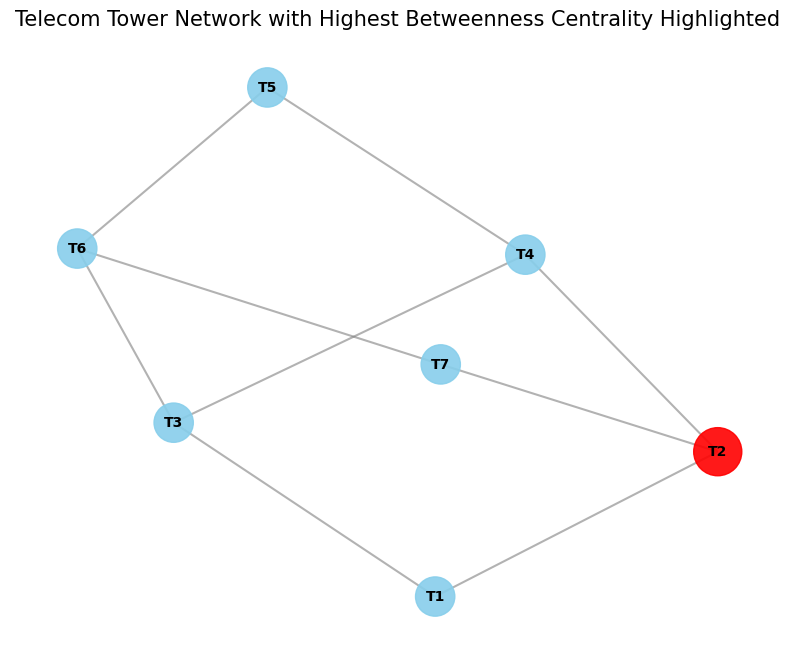

In [ ]:
plt.figure(figsize=(10, 8))
pos_towers = nx.spring_layout(G_towers, seed=42)

highest_betweenness_tower = centrality_df['Betweenness Centrality'].idxmax()

node_colors_map = []
node_sizes_map = []
for node in G_towers.nodes():
    if node == highest_betweenness_tower:
        node_colors_map.append('red')
        node_sizes_map.append(1200)
    else:
        node_colors_map.append('skyblue')
        node_sizes_map.append(800)

nx.draw_networkx_nodes(G_towers, pos_towers, node_color=node_colors_map, node_size=node_sizes_map, alpha=0.9)

nx.draw_networkx_edges(G_towers, pos_towers, width=1.5, alpha=0.6, edge_color='gray')

nx.draw_networkx_labels(G_towers, pos_towers, font_size=10, font_weight='bold', font_color='black')

plt.title('Telecom Tower Network with Highest Betweenness Centrality Highlighted', size=15)
plt.axis('off')
plt.show()


### Observations on the Telecom Tower Network

Based on the computed metrics and visualization:

*   **T4 and T3 are the most critical towers**: T4 has the highest betweenness centrality (0.5), indicating it lies on many shortest paths between other towers. T3 also shows high betweenness, and along with T4, they have the highest degree (4 connections each), making them crucial for network connectivity. If T4 or T3 fails, it would significantly disrupt communication flow.
*   **High connectivity and efficiency**: The network is fully connected, meaning all towers can reach each other. The average path length is likely small given the relatively high centrality values, suggesting an efficient network for transmitting signals between towers.
*   **T1, T5, and T7 are peripheral**: These towers have lower centrality scores compared to T2, T3, T4, and T6. While essential for their local connections, their failure would have a less widespread impact on overall network connectivity compared to T3 or T4, as they do not serve as 'bridges' for as many communication paths.